# Exploratory Data Analysis

**Author**: Mert Acar\
**Date**: 19.12.2024

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/product_user_reviews.csv")

In [3]:
print("=== Basic Dataset Information ===")
print(f"+ Dataset Shape: {df.shape}")
print(f"+ Total number of unique products: {df['product_id'].nunique()}")
print(f"+ Total number of unique users: {df['user_id'].nunique()}")
print(f"+ Number of reviews per user: {len(df) / df['user_id'].nunique():.3f}")
print(f"+ Total duplicate entries: {df.duplicated().sum()}")
print("+ Column Information & Missing Values:")
print(df.info())

=== Basic Dataset Information ===
+ Dataset Shape: (31371, 9)
+ Total number of unique products: 5059
+ Total number of unique users: 29415
+ Number of reviews per user: 1.066
+ Total duplicate entries: 0
+ Column Information & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31371 entries, 0 to 31370
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   review_date       31371 non-null  object 
 1   product_id        31371 non-null  object 
 2   product_name      31371 non-null  object 
 3   product_category  31371 non-null  object 
 4   user_id           31371 non-null  object 
 5   price             31371 non-null  float64
 6   review_text       31371 non-null  object 
 7   discount_rate     31371 non-null  float64
 8   rating            31371 non-null  int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 2.2+ MB
None


In [4]:
print("Sample row:\n==========")
for key, value in df.sample(n=1).iloc[0].to_dict().items():
    print(f"+ {key}: {value}")

Sample row:
+ review_date: 2020-05-24
+ product_id: B079TTRW3L
+ product_name: Polka Dot Wall Decals (63) Girls Room Wall Decor Stickers, Wall Dots, Vinyl Circle Peel & Stick DIY Bedroom, Playroom, Kids Room, Baby Nursery Toddler to Teen Bedroom Decoration Gift 3"-6.5" (Teal)
+ product_category: Amazon Home | Wall Decals
+ user_id: AF7GIJJITMT2U2MDFTM353NXETYQ
+ price: 12.99
+ review_text: Polka dotted my wall!. These are super easy to use and fun. The only problem I had was making sure I had enough of each size circle...
+ discount_rate: 0.0
+ rating: 5


The data does not appear to have missing or duplicate values. The reviews are plain english text with no specific format, however, some of the reviews include HTML tags and emojies. Those need to be cleaned

## Statistical Analysis

### Ratings Distribution

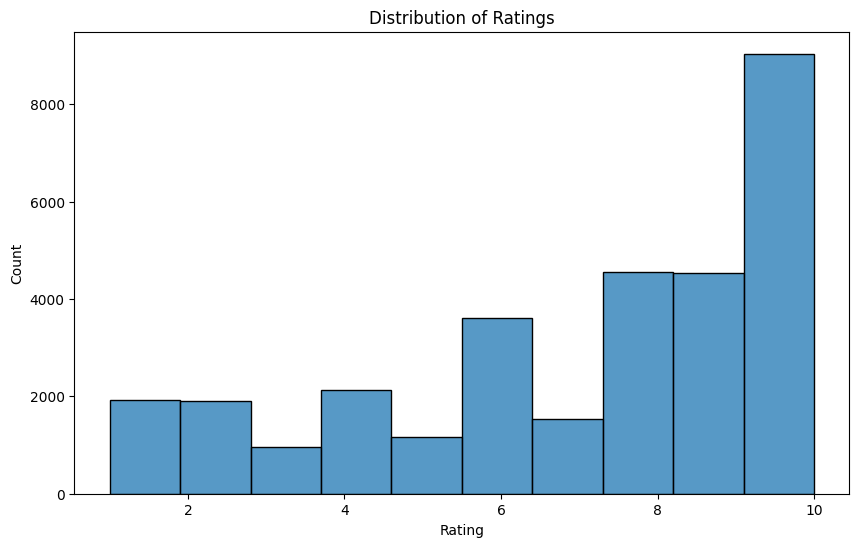

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='rating', bins=10)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()
plt.close()

In [6]:
print("\n=== Ratings Statistics ===")
print(df['rating'].describe())
print()
print(df['rating'].value_counts(normalize=True).sort_index() * 100)


=== Ratings Statistics ===
count    31371.000000
mean         7.110229
std          2.898929
min          1.000000
25%          5.000000
50%          8.000000
75%         10.000000
max         10.000000
Name: rating, dtype: float64

rating
1      6.136240
2      6.094801
3      3.050588
4      6.824774
5      3.710433
6     11.491505
7      4.880303
8     14.538905
9     14.452839
10    28.819610
Name: proportion, dtype: float64


There's a strong positive skew in ratings:

 + 28.82% of ratings are 10/10
 + 57.81% of ratings are 8 or higher
 + Only 15.28% of ratings are 3 or lower

This suggests a significant positive bias in ratings. We might need to try to deal with this using stratification or resampling techniques

### Category Distribution

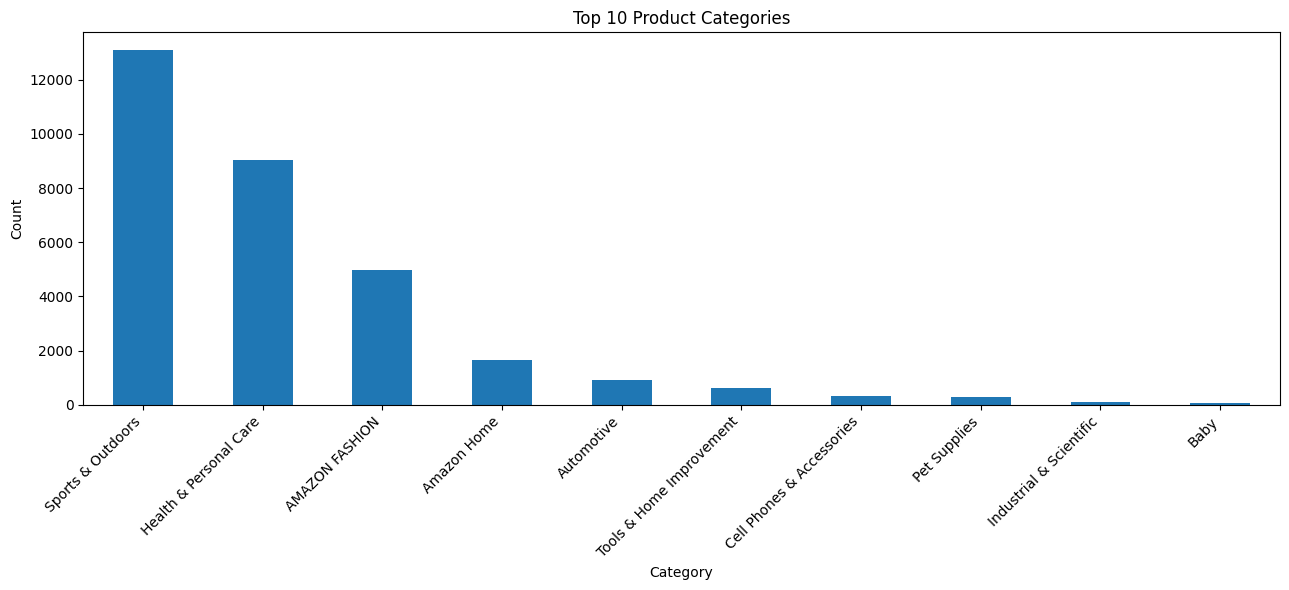

In [7]:
df['main_category'] = df['product_category'].str.split('|').str[0].str.strip()
category_counts = df['main_category'].value_counts()
plt.figure(figsize=(13, 6))
category_counts.head(10).plot(kind='bar')
plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

In [8]:
avg_rating_by_category = df.groupby('main_category')['rating'].agg(['mean', 'count', 'median', 'std']).sort_values('count', ascending=False)
print("=== Average Rating by Category ===")
print(avg_rating_by_category)

=== Average Rating by Category ===
                               mean  count  median       std
main_category                                               
Sports & Outdoors          7.286467  13094     8.0  2.772331
Health & Personal Care     6.659551   9041     8.0  3.187436
AMAZON FASHION             7.309500   4979     8.0  2.692044
Amazon Home                7.479641   1670     8.0  2.676799
Automotive                 7.898582    917     8.0  2.267477
Tools & Home Improvement   7.247619    630     8.0  2.870100
Cell Phones & Accessories  5.718475    341     6.0  3.122487
Pet Supplies               6.862745    306     8.0  2.813454
Industrial & Scientific    6.892473     93     8.0  2.961574
Baby                       7.102941     68     8.0  2.781279
Computers                  7.731343     67     9.0  2.643357
All Electronics            6.285714     56     6.5  3.306821
Grocery                    5.833333     48     6.0  3.263814
Office Products            5.925926     27     6.0

Top 3 categories dominate the dataset:
 + Sports & Outdoors (41.7% of reviews)
 + Health & Personal Care (28.8%)
 + AMAZON FASHION (15.9%)
 
These three categories account for 86.4% of all reviews.

Highest average ratings:
 + Video Games (9.00, but small sample size)
 + Automotive (7.90)
 + Computers (7.73)

Lowest average ratings:
 + Cell Phones & Accessories (5.72)
 + Grocery (5.83)
 + Office Products (5.93)

Based on these observations, category binning (e.g. \[Sports & Outdoors, Health & Personal Care, AMAZON FASHION, Others\]) can be beneficial to balance out the predictions

### Price & Discount Distributions

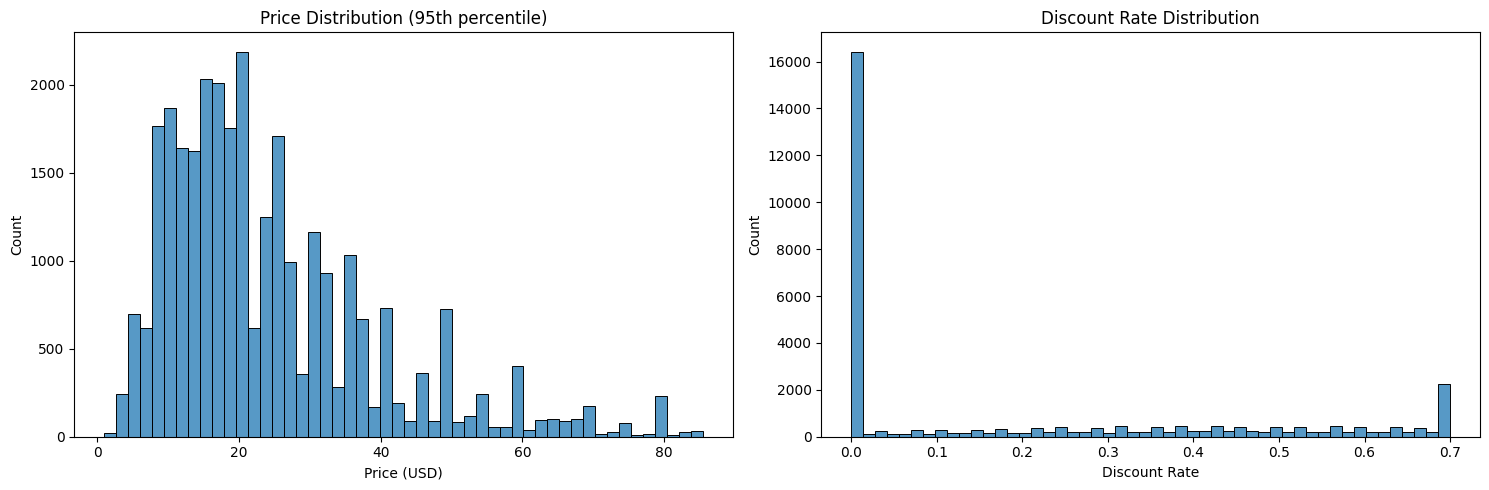

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

price_threshold = df['price'].quantile(0.95)
sns.histplot(data=df[df['price'] <= price_threshold], x='price', bins=50, ax=ax1)
ax1.set_title('Price Distribution (95th percentile)')
ax1.set_xlabel('Price (USD)')

sns.histplot(data=df, x='discount_rate', bins=50, ax=ax2)
ax2.set_title('Discount Rate Distribution')
ax2.set_xlabel('Discount Rate')
plt.tight_layout()
plt.show()
plt.close()

In [10]:
print("=== Price Statistics ===")
print(df['price'].describe())
print()
print("=== Discount Rate Statistics ===")
print(df['discount_rate'].describe())

=== Price Statistics ===
count    31371.000000
mean        35.047901
std         94.483436
min          0.990000
25%         13.970000
50%         19.990000
75%         33.970000
max       4449.000000
Name: price, dtype: float64

=== Discount Rate Statistics ===
count    31371.000000
mean         0.201364
std          0.254132
min          0.000000
25%          0.000000
50%          0.000000
75%          0.420000
max          0.700000
Name: discount_rate, dtype: float64


In [11]:
print(f"+ Skew in prices: {df['price'].skew():.3f}")

+ Skew in prices: 25.277


We can see the prices are heavily right-skewed which hinders statistical model estimation. We need to come up with a transformation to deal with the skews in the prices. On the discount rate distribution we again may need to use binning to capture "zones" rather than specific rates. These all need to be tested with the correlation analysis or $R^2$ score from a simple regressor

### Review Distributions

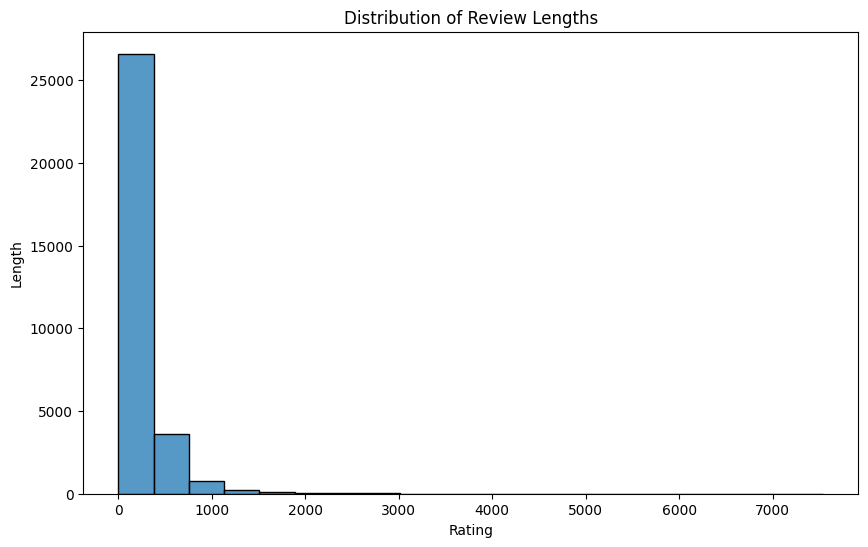

=== Review Length Statistics ===
count    31371.000000
mean       224.403940
std        276.963515
min          4.000000
25%         74.000000
50%        146.000000
75%        274.000000
max       7538.000000
Name: review_length, dtype: float64


In [12]:
# Review Length Analysis
df['review_length'] = df['review_text'].str.len()
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='review_length', bins=20)
plt.title('Distribution of Review Lengths')
plt.xlabel('Rating')
plt.ylabel('Length')
plt.show()
plt.close()
print("=== Review Length Statistics ===")
print(df['review_length'].describe())

It is beneficial for us that most of the reviews are less than 1000 characters long (224 on average). We can easily use a text encoding pre-trained transformer model with a reasonably small window size to encode the reviews into embedding vectors to create features for the predictor model. These transformer models are built to either pad the short input to a predefined length or truncate the long ones to fit the window. From the distribution above, we can see that our dataset will not lose much information during this encoding. 

### Correlation Analysis

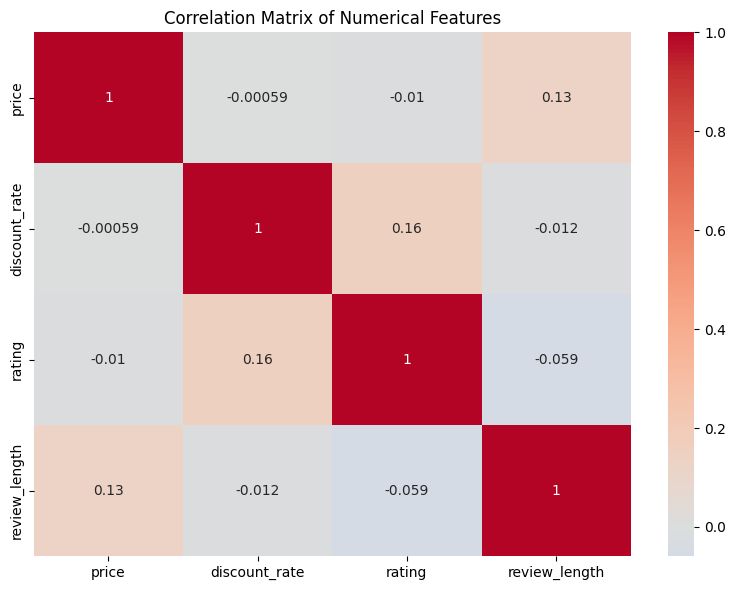

In [13]:
numerical_cols = ['price', 'discount_rate', 'rating', 'review_length']
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()
plt.close()

We see that the features at their current form does not have much predictive power on the ratings. We need to do a fair amount of feature engineering to craft good features for our model to learn on.

## Feature Crafting

#### Price Features

First of all we need to address the right-skew in the price distribution in order to get a well behaving distribution. We can achieve this using a logarithm transformation to squash the distances. One such transformation that is highly used is: $$y = ln(1 + x)$$ which passes through the origin and widely used.

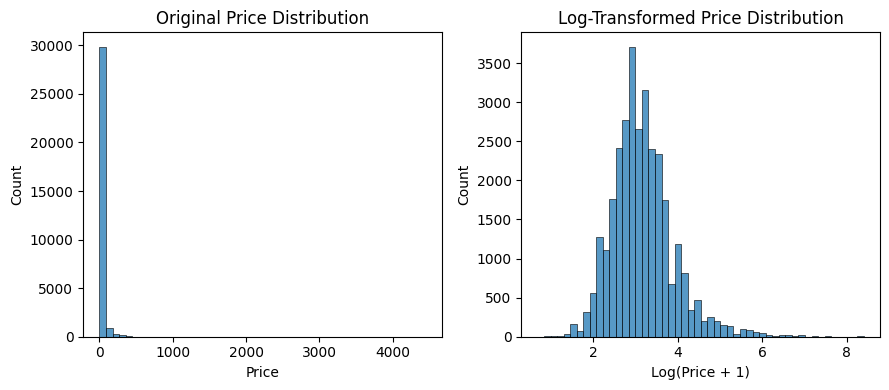

Skewness comparison:
Original price skewness: 25.28
Log-transformed price skewness: 1.09

Correlation with rating:
Original price correlation: -0.010
Log-transformed correlation: 0.020


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Original distribution
sns.histplot(data=df, x='price', bins=50, ax=axes[0])
axes[0].set_title('Original Price Distribution')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Count')

# Log transformation
df['price_log'] = np.log1p(df['price'])  # log1p to handle zeros
sns.histplot(data=df, x='price_log', bins=50, ax=axes[1])
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

print("Skewness comparison:")
print(f"Original price skewness: {df['price'].skew():.2f}")
print(f"Log-transformed price skewness: {df['price_log'].skew():.2f}")
print()
print("Correlation with rating:")
print(f"Original price correlation: {df['price'].corr(df['rating']):.3f}")
print(f"Log-transformed correlation: {df['price_log'].corr(df['rating']):.3f}")

We see that the skewness is much better and the correlation has increased (albeit not meaningfully). Skewness alone will help the model to behave better.

#### Discount Features

In [15]:
df['discount_bracket'] = pd.cut(
    df['discount_rate'],
    bins=[-float('inf'), 0, 0.2, 0.4, 0.6, float('inf')],
    labels=['no discount', 'low', 'medium', 'high', 'very high']
)

print("Average Rating by Discount Bracket:")
bracket_stats = df.groupby('discount_bracket', observed=True)['rating'].agg(['mean', 'count', 'std']).round(3)
print(bracket_stats)

Average Rating by Discount Bracket:
                   mean  count    std
discount_bracket                     
no discount       6.988  16310  2.968
low               5.892   2863  2.963
medium            6.998   4112  2.930
high              7.213   4203  2.803
very high         8.531   3883  1.905


We can see bracketing is useful since they capture these distinct "zones" of discount effects:

 + The "disappointment zone" (0-20%): Lower ratings than no discount
 + The "satisfaction zone" (20-60%): Gradually improving ratings
 + The "delight zone" (>60%): Dramatically higher ratings
 
Very high discounts (as a bracket) not only have higher ratings but also more consistent ratings (lower std)

#### Category Features

In [16]:
top_categories = ['Sports & Outdoors', 'Health & Personal Care', 'AMAZON FASHION']
df['category_grouped'] = df['main_category'].apply(
    lambda x: x if x in top_categories else 'Other'
)

# Calculate average rating by category
print("Average Rating by Category:")
for cat in top_categories + ["Other"]:
    category_subset = df[df["category_grouped"] == cat]
    count = category_subset.shape[0]
    mean_rating = category_subset['rating'].mean()
    std_rating = category_subset['rating'].std()
    print(f"\n{cat}:")
    print(f"Mean Rating: {mean_rating:.3f}")
    print(f"Std Rating: {std_rating:.3f}")
    print(f"Count: {count}")

Average Rating by Category:

Sports & Outdoors:
Mean Rating: 7.286
Std Rating: 2.772
Count: 13094

Health & Personal Care:
Mean Rating: 6.660
Std Rating: 3.187
Count: 9041

AMAZON FASHION:
Mean Rating: 7.309
Std Rating: 2.692
Count: 4979

Other:
Mean Rating: 7.292
Std Rating: 2.763
Count: 4257


We can see that the distribution across categories are more regular with the ratings and counts.